# Engine and Cloud recipes — executed

Short recipes from Parts B and C of the *Siamang Cookbook: Usage Scenarios*, executed cell by cell with their outputs. Each cell is self-contained (imports included). Platform-only Cloud blocks (scripts that need `siamang_cloud.db`, `siamang.yaml`, REST calls) are kept as reference text; the SDK's pure-pandas functions and the webhook receiver run here — the SDK block needs the `siamang-cloud` package, which ships with the platform (install it from the platform repository's `sdk/` directory to run it locally).

# Part B — Engine recipes by pipeline stage

Short, focused recipes that complement the scenarios and the short cookbook (`docs/cookbook.md`).
Each block is self-contained unless it says otherwise.

## B1. Authoring patterns

### Reusable label scales and battery factories

Define a scale once and stamp out items with a factory; the `construct` field groups them
for the codebook and for `scale_alpha()` / `create_index()` later.

In [1]:
import siamang as sg

AGREE5 = {1: "Strongly disagree", 2: "Disagree", 3: "Neutral", 4: "Agree", 5: "Strongly agree"}

def battery(prefix: str, items: dict[str, str], construct: str) -> list[sg.Variable]:
    return [sg.Variable(f"{prefix}_{key}", scale="ordinal", label=label, labels=AGREE5,
                        construct=construct)
            for key, label in items.items()]

efficacy = battery("eff", {
    "voice": "People like me have a say in what the government does",
    "complex": "Politics is too complicated to understand",
    "care": "Politicians care what people like me think",
}, construct="political_efficacy")

q_efficacy = sg.Matrix("How much do you agree with each statement?", var=efficacy)
print([v.name for v in efficacy], q_efficacy.id)
# → ['eff_voice', 'eff_complex', 'eff_care'] None      (compiled id falls back to matrix_eff_voice)

['eff_voice', 'eff_complex', 'eff_care'] None


### Choosing the MultiChoice layout by the data you want back

| You want… | Bind with | `simulate()` gives | the browser stores |
| :--- | :--- | :--- | :--- |
| one column holding the set of codes | `var=one_variable` (array mode) | a Python list per row | a JSON list → list |
| one 0/1 column per option (SPSS style) | `vars=[v1, v2, ...]` (wide mode) | one int column per variable | a list of *variable names* under `multi_<v1>` |

Array mode supports `exclusive=[code]` ("None of these" clears the rest) and
`min_answers` / `max_answers`; wide mode caps `max_answers` at the number of variables.
Normalise browser data with `flatten_responses()` (A1.4); explode array columns for
"mentions" tables (B6).

In [2]:
import siamang as sg

hobbies = sg.Variable("hobbies", scale="nominal", label="Hobbies",
                      labels={1: "Music", 2: "Sport", 3: "Reading", 99: "None"})
q_array = sg.MultiChoice("Which hobbies do you have?", var=hobbies, exclusive=[99], max_answers=3)

owns = [sg.Variable(f"owns_{d}", scale="nominal", label=f"Owns a {d}", labels={0: "No", 1: "Yes"})
        for d in ("phone", "laptop", "tablet")]
q_wide = sg.MultiChoice("Which of these do you own?", vars=owns)
print(q_array.mode, q_wide.mode, q_wide.id or "multi_" + owns[0].name)
# → array wide multi_owns_phone

array wide multi_owns_phone


### Options with media and per-option visibility

In [3]:
import siamang as sg
from siamang.core import Media, Option

age = sg.Variable("age", scale="ratio", label="Age")
logo = sg.Variable("logo", scale="nominal", label="Preferred logo", labels={1: "A", 2: "B", 3: "C"})

q_logo = sg.SingleChoice(
    "Which logo do you prefer?", var=logo, display="buttons",
    choices=[
        Option(1, "Logo A", media=Media("https://cdn.example.com/logo-a.png", alt="Logo A")),
        Option(2, "Logo B", media=Media("https://cdn.example.com/logo-b.png", alt="Logo B")),
        Option(3, "Logo C (adults only)", show_if=age.ge(18)),
    ],
    media=Media("https://cdn.example.com/brief.mp4", caption="Watch the 20-second brief first"),
)
# Extensionless URLs need an explicit kind:
banner = Media("https://cdn.example.com/asset?id=42", kind="image", alt="Campaign banner")
print([o.code for o in q_logo.choices], banner.kind)
# → [1, 2, 3] image

[1, 2, 3] image


### Translating the respondent-facing chrome

Question texts are whatever you write; the navigation and system strings come from
`UIConfig`. Combine with the compiler option `language=` (sets the page `lang` attribute).

In [4]:
import dataclasses
from siamang.frontend import get_preset

ui_de = dataclasses.replace(
    get_preset("academic"),
    next_button_text="Weiter", prev_button_text="Zurück", submit_button_text="Absenden",
    submitting_text="Antworten werden gesendet…", required_text="Pflichtfeld",
    completion_title="Vielen Dank!", completion_body="Ihre Antworten wurden gespeichert.",
    page_text="Seite", of_total_text="von",
)
# survey.deploy(..., ui=ui_de, language="de")
print(ui_de.next_button_text, ui_de.font_preset)
# → Weiter academic

Weiter academic


## B2. Logic and routing

### Building and testing expressions

Typed expressions are inspectable, evaluable and serialisable — test them like code.

In [5]:
import siamang as sg
from siamang.core import AND, OR, NOT, Expression, compare

age = sg.Variable("age", scale="ratio")
region = sg.Variable("region", scale="nominal", labels={1: "A", 2: "B", 3: "C"})
consent = sg.Variable("consent", scale="nominal", labels={1: "Yes", 0: "No"})

gate = AND(consent.eq(1), age.ge(18), OR(region.eq(1), region.eq(2)))
assert gate.evaluate({"consent": 1, "age": 30, "region": 2})
assert not gate.evaluate({"consent": 1, "age": 30, "region": 3})
assert sorted(gate.variables()) == ["age", "consent", "region"]
assert Expression.from_dict(gate.to_dict()) == gate                 # lossless JSON round trip
print(gate.to_surveyjs())
# → (({consent} = 1) and ({age} >= 18)) and (({region} = 1) or ({region} = 2))
print(compare("age", ">=", 18).to_surveyjs(), (~region.isin([3])).to_surveyjs())
# → {age} >= 18 not ({region} in [3])

(({consent} = 1) and ({age} >= 18)) and (({region} = 1) or ({region} = 2))
{age} >= 18 not ({region} in [3])


Remember: `==` and `!=` are *not* overloaded on `Variable` (`gender == 1` is a plain
`bool`); always use `.eq()` / `.ne()`.

### Page-level gates must be SurveyJS-exportable

`validate()` runs an export check on every **page** `show_if` and rejects the `in [...]`
syntax that `isin()` / `notin()` produce. The same expression is accepted on blocks,
questions, options and in `next_if`.

In [6]:
import siamang as sg
from siamang.core import OR

age = sg.Variable("age", scale="ratio")
region = sg.Variable("region", scale="nominal", labels={1: "A", 2: "B", 3: "C"})
consent = sg.Variable("consent", scale="nominal", labels={1: "Yes", 0: "No"})
q_age, q_region = sg.NumericInput("Age?", var=age), sg.SingleChoice("Region?", var=region)
q_consent = sg.SingleChoice("Consent?", var=consent)

try:
    sg.Questionnaire(title="x", pages=[
        sg.Page("p1", items=[q_age, q_region]),
        sg.Page("p2", items=[q_consent], show_if=region.isin([1, 2])),
    ]).validate()
except ValueError as e:
    print("EXPECTED (demonstration) — validate() rejects isin() in a page gate:", e)
# → ValueError: Page 'p2' show_if contains tokens unsupported by surveyjs: {region} in [1, 2]

sg.Questionnaire(title="x", pages=[
    sg.Page("p1", items=[q_age, q_region]),
    sg.Page("p2", items=[q_consent], show_if=OR(region.eq(1), region.eq(2))),   # fine
]).validate()

EXPECTED (demonstration) — validate() rejects isin() in a page gate: Page 'p2' show_if contains tokens unsupported by surveyjs: {region} in [1, 2]


### Routing: `next_if` with typed expressions, `default_next`, `skip_to`

In [7]:
import siamang as sg
from siamang.core import DisqualificationPage, FinalPage

age = sg.Variable("age", scale="ratio")
consent = sg.Variable("consent", scale="nominal", labels={1: "Yes", 0: "No"})
survey = sg.Questionnaire(title="routing", pages=[
    sg.Page("screener", items=[sg.NumericInput("Age?", var=age)],
            next_if=[(age.lt(18), "too_young")],      # (Expression, page name), first match wins
            default_next="main"),                     # redundant here → REDUNDANT_NAVIGATION lint
    sg.Page("main", items=[sg.SingleChoice("Consent?", var=consent, skip_to="done")]),
    DisqualificationPage("too_young", body="<p>Sorry.</p>", show_if=age.lt(18)),
    FinalPage("done", body="<p>Thanks.</p>"),
])
survey.validate()
print([w.code for w in survey.lint()])
# → ['REDUNDANT_NAVIGATION']

['REDUNDANT_NAVIGATION']


Semantics in the 0.6.0 React runtime: when the respondent presses Next, a `skip_to` on the
first *answered* visible question wins (unconditionally), then the first matching `next_if`,
then `default_next`, then the next page in order. `validate()` checks that targets exist
and that the `next_if`/`default_next` graph is acyclic with every page reachable; `skip_to`
edges are excluded from that graph, so review skip chains by hand. Routing is executed by
the React runtime only (the SurveyJS runtime ignores it) and is not reproduced by
`simulate()`, which honours typed page/question gates only.

### `FilterRule` for analysis-time filters

`FilterRule` never compiles to the frontend — use it to name a subgroup in Python and apply
it to answers dicts or DataFrame rows.

In [8]:
import pandas as pd
from siamang.core import FilterRule

adults_in_capital = FilterRule(
    predicate=lambda a: a.get("age", 0) >= 18 and a.get("region") == 1,
    description="Adults living in the capital",
)
frame = pd.DataFrame({"age": [17, 30, 40], "region": [1, 1, 2]})
subset = frame[frame.apply(lambda row: adults_in_capital.evaluate(row.to_dict()), axis=1)]
print(len(subset))
# → 1

1


## B3. Quotas and scripts

### The quota plan: define, validate, test, attach, monitor

In [9]:
import siamang as sg
from siamang.core import Quota, validate_options

gender = sg.Variable("gender", scale="nominal", labels={1: "Woman", 2: "Man"})
survey = sg.Questionnaire(title="q", pages=[sg.Page("p", items=[sg.SingleChoice("Gender?", var=gender)])])

options = {"quota": [Quota("gender", 1, limit=200), Quota("gender", 2, limit=200)]}
validate_options(survey, options)                    # also run by `siamang validate`

try:
    validate_options(survey, {"quotas": options["quota"]})
except ValueError as e:
    print(e)
# → Compiler options use key 'quotas'; the compiler reads 'quota'. Rename it or the quotas are ignored.

cell = options["quota"][0]
print(cell.reached([{"gender": 1}] * 199), cell.reached([{"gender": 1}] * 200))
# → False True
# survey.deploy(**options)  → cells provisioned; monitor with result.collect() + cell.reached(...)

Compiler options use key 'quotas'; the compiler reads 'quota'. Rename it or the quotas are ignored.
False True


Each `deploy()` provisions a fresh instance with zeroed counters, so changing a limit
mid-field means a new deployment (and a new `survey_id`). See A1.5 for what the runtime
enforces.

### Scripts: factories, custom snippets, `context`

In [10]:
import siamang as sg

shuffle_party = sg.Script.randomize_options("party")          # onQuestionShow, target="party"
timer = sg.Script.timed_question("stroop", seconds=20)        # auto-advance after 20 s
match = sg.Script.validate_fields_match("email", "email2", message="E-mail addresses differ.")
log_dwell = sg.Script(
    name="log_dwell", trigger="onPageExit", context={"endpoint": "/diagnostics"},
    code="api.post(context.endpoint, { page: answers.__pages__, left_at: utils.now() });",
)
stamp = sg.Script(
    name="stamp", trigger="onSubmit",
    code="answers.user_agent = navigator.userAgent; answers.finished_at = utils.now();",
)
try:
    sg.Script(code="x", trigger="onWhatever")
except ValueError as e:
    print(e)
# → Unknown trigger 'onWhatever'. Allowed triggers: onAnswer, onInit, onPageEnter, onPageExit, onQuestionShow, onRandomize, onSubmit.

Unknown trigger 'onWhatever'. Allowed triggers: onAnswer, onInit, onPageEnter, onPageExit, onQuestionShow, onRandomize, onSubmit.


Inside a snippet: `answers` (read/write; special keys `__options__`, `__pages__`,
`__errors__`, `__timers__`), `utils` (`shuffle`, `sample(arr, n)`, `clamp`, `debounce`,
`now`, `formatDate`), `api.get/post`, and `context` exactly as passed. Anything you write
into `answers` is submitted with the response (that is how A3 captures `panel_id` and A4
assigns arms). Cross-field validation messages go into `answers.__errors__[field]` from an
`onAnswer` script; an `onSubmit` script runs too late to block submission.
`sandbox=True` is a declared intent — the 0.6.0 runtime does not isolate snippets from
`window`.

## B4. Validation and testing

### Reading lint output

In [11]:
import siamang as sg

age = sg.Variable("age", scale="ratio")
nominal = sg.Variable("mood", scale="nominal", labels={1: "Low", 2: "High"})
unlabelled = sg.Variable("colour", scale="nominal")
draft = sg.Questionnaire(title="draft", pages=[
    sg.Page("p1", items=[
        sg.NumericInput("Age?", var=age),
        sg.LikertScale("Mood?", var=nominal, points=5),                        # scale mismatch
        sg.SingleChoice("Colour?", var=unlabelled, required=True, show_if=age.ge(18)),
    ]),
    sg.Page("p2", items=[]),                                                   # empty page
])
print("Lint findings on a deliberately flawed draft (this is what lint is for):")
for w in draft.lint(level="strict"):
    print(f"[{w.severity}] {w.code} ({w.location})")
# → [error] EMPTY_PAGE (p2)
# → [warning] LIKERT_POINTS_LABEL_MISMATCH (mood)
# → [error] INCOMPATIBLE_QUESTION_SCALE (mood)
# → [warning] REQUIRED_CONDITIONAL (colour)
# → [error] CATEGORICAL_WITHOUT_LABELS (colour)
try:
    draft.validate(strict=True)
except ValueError as e:
    print("EXPECTED (demonstration) — validate(strict=True) refuses the draft:", str(e)[:60], "...")

Lint findings on a deliberately flawed draft (this is what lint is for):
[error] EMPTY_PAGE (p2)
[warning] LIKERT_POINTS_LABEL_MISMATCH (mood)
[error] INCOMPATIBLE_QUESTION_SCALE (mood)
[warning] REQUIRED_CONDITIONAL (colour)
[error] CATEGORICAL_WITHOUT_LABELS (colour)
EXPECTED (demonstration) — validate(strict=True) refuses the draft: Strict questionnaire validation failed: EMPTY_PAGE, INCOMPAT ...


The basic level (`lint()`) has eleven rules — structural ones (`EMPTY_QUESTIONNAIRE`,
`EMPTY_PAGE`, `REDUNDANT_NAVIGATION`, `MISSING_NAVIGATION`) plus codebook/logic checks
(`UNKNOWN_CONDITION_VALUE`, `CONTRADICTORY_VISIBILITY`, `EXCLUSIVE_CODE_UNKNOWN`,
`OPTION_CODE_WITHOUT_LABEL`, `LIKERT_POINTS_LABEL_MISMATCH`, `MISSING_CODE_NOT_IN_LABELS`,
`RANGE_LABEL_MISMATCH`); strict adds `REQUIRED_CONDITIONAL`, `INCOMPATIBLE_QUESTION_SCALE`,
`CATEGORICAL_WITHOUT_LABELS`, `UNUSED_VARIABLE`. Error-severity findings fail
`validate(strict=True)` and `siamang validate --strict` (exit code 2).

### A test file for any survey

The A1 tests are the template: validate strictly, validate the options, evaluate the
gates, simulate and assert the missingness pattern, and check reproducibility. Two more
assertions worth adding for studies with an explicit registry:

In [12]:
import siamang as sg

age = sg.Variable("age", scale="ratio", label="Age", valid_range=(18, 99))
vm = sg.VariableMap(); vm.add(age)
survey = sg.Questionnaire(title="t", variables=vm,
                          pages=[sg.Page("p", items=[sg.NumericInput("Age?", var=age)])])
data = survey.simulate(n=50, seed=42)
assert set(data.frame.columns) == set(vm)                       # every variable, nothing else
assert not [i for i in vm.validate_frame(data.frame) if i.severity == "error"]
print("ok")

ok


## B5. Deployment and configuration

### The configuration file from Python

In [13]:
import os, tempfile
from pathlib import Path
from siamang.config import Config, load, save

path = Path(tempfile.mkdtemp()) / "siamang.toml"          # use ~/.siamang.toml for real
cfg = Config(
    defaults={"backend": "local", "frontend": "local"},
    backends={"supabase": {"url": "https://x.supabase.co", "anon_key": "a", "service_key": "s"}},
    frontends={"vercel": {"token": "t", "project_name": "civic-trust"}},
    profiles={"production": {"backend": "supabase", "frontend": "vercel"}},
    path=None,
)
save(cfg, path)                                            # chmod 600 applied
print(oct(path.stat().st_mode)[-3:])
# → 600

os.environ["SIAMANG_SUPABASE_URL"] = "https://env.supabase.co"   # environment wins over the file
cfg = load(path)
print(cfg.backend("supabase")["url"], cfg.with_profile("production").default_backend())
# → https://env.supabase.co supabase
del os.environ["SIAMANG_SUPABASE_URL"]

600
https://env.supabase.co supabase


`siamang deploy` loads `~/.siamang.toml` automatically (0.6.0), applies `--profile`, and
forwards the matching `[backends.*]` / `[frontends.*]` blocks as adapter kwargs; `local`
blocks are not forwarded. `VERCEL_TOKEN` and `NETLIFY_AUTH_TOKEN` are read directly by
their adapters when the kwarg is empty — the CI-friendly way to keep tokens out of files.

### Which adapters are available, and Supabase SQL by hand

In [14]:
from siamang.deploy import list_backends, list_frontends
from siamang.deploy.backends.supabase import generate_migration_sql

print(list_backends(), list_frontends())
# → ['gsheets', 'local', 'supabase'] ['local', 'netlify', 'vercel']
print(generate_migration_sql().splitlines()[0])
# → -- Siamang: Supabase migration script

['gsheets', 'local', 'supabase'] ['local', 'netlify', 'vercel']
-- Siamang: Supabase migration script


Third-party adapters register under the `siamang.backends` / `siamang.frontends` entry
points and are picked up by name (see the short cookbook).

### Reading the preview database

`siamang preview` stores answers in `survey.db` and prints the survey id on start-up:

```python
# not run here: needs a preview session's survey id
from siamang.deploy.backends.local import LocalBackend
frame = LocalBackend(path="survey.db").get_responses(survey_id="42a1c0e9d3f5")
# columns: your variables (+ matrix/multi payloads), __options__/__pages__/__errors__, _response_id, _submitted_at
```

## B6. Data cleaning

### The order of operations

1. `data.validate()` — structural problems first (missing columns, out-of-range, unknown codes).
2. Sentinel cleanup — `"na"`, `"__other__"`, `"__none__"` (A2.3), list/dict payloads (A1.4).
3. `apply_missing_values()` — declared codes → `pd.NA`; then `pd.to_numeric` on affected columns.
4. `recode()` / `recode_values()` / `derive()` / `create_index()` — every derived variable is registered.
5. `with_weight()` — then `data.analysis.*` with `weighted=True`.

`derive()` evaluates an `Expression` row by row with `bool()`; run it on plain numeric
columns (before `apply_missing_values()`, or after `pd.to_numeric`), because `bool(pd.NA)`
raises.

### Collapsing codes with descriptive labels

`recode_values()` registers the new variable with labels `{code: str(code)}`. Overwrite
the entry to get readable labels; `processing.recode()` is a metadata-free shortcut that
drops the registry entirely.

In [15]:
import dataclasses
import pandas as pd
import siamang as sg

remote = sg.Variable("remote", scale="ordinal", label="Remote work",
                     labels={1: "Never", 2: "Rarely", 3: "Hybrid", 4: "Mostly", 5: "Fully"})
vm = sg.VariableMap(); vm.add(remote)
data = sg.SurveyData(frame=pd.DataFrame({"remote": [1, 2, 3, 4, 5, 3, 2]}), variables=vm)

data = data.recode_values("remote", {1: 1, 2: 1, 3: 2, 4: 3, 5: 3}, into="remote3",
                          label="Remote work (3 groups)", scale="ordinal")
print(data.variables["remote3"].labels)
# → {1: '1', 2: '2', 3: '3'}
data.variables["remote3"] = dataclasses.replace(
    data.variables["remote3"], labels={1: "Never/rarely", 2: "Hybrid", 3: "Mostly/fully"})
print(data.report.freq("remote3").to_frame()[["Label", "N"]].to_string(index=False))

quick = data.processing.recode("remote", {1: 1, 2: 1, 3: 2, 4: 3, 5: 3})
print(quick.variables)       # → None — metadata gone

{1: '1', 2: '2', 3: '3'}
       Label  N
Never/rarely  3
      Hybrid  2
Mostly/fully  2
       Total  7
None


### Mention tables for array-mode MultiChoice

In [16]:
import pandas as pd
import siamang as sg

hobbies = sg.Variable("hobbies", scale="nominal", label="Hobbies",
                      labels={1: "Music", 2: "Sport", 3: "Reading", 99: "None"})
frame = pd.DataFrame({"hobbies": [[1, 2], [3], [99], [], None, [1, 3]]})
answered = frame["hobbies"].map(lambda s: isinstance(s, list) and len(s) > 0)
long = frame.loc[answered, ["hobbies"]].explode("hobbies")
mentions = (long["hobbies"].value_counts().rename("n").to_frame()
            .assign(percent=lambda t: (t["n"] / answered.sum() * 100).round(1)))
mentions.index = mentions.index.map(hobbies.labels)
print(mentions)

         n  percent
hobbies            
Music    2     50.0
Reading  2     50.0
Sport    1     25.0
None     1     25.0


### Post-stratification weights without extra libraries

`rake()` from A1.6 handles several margins; for one margin, cell weights are a one-liner.
Register the weight, attach it with `with_weight()`, and report the effective sample size.

In [17]:
import numpy as np
import pandas as pd
import siamang as sg

gender = sg.Variable("gender", scale="nominal", label="Gender", labels={1: "Woman", 2: "Man"})
vm = sg.VariableMap(); vm.add(gender)
rng = np.random.default_rng(1)
data = sg.SurveyData(frame=pd.DataFrame({"gender": rng.choice([1, 2], 500, p=[0.65, 0.35])}),
                     variables=vm)

target = pd.Series({1: 0.51, 2: 0.49})
observed = data.frame["gender"].value_counts(normalize=True)
w = data.frame["gender"].map(target / observed)
data = data.with_frame(data.frame.assign(w=w / w.mean()))
data.variables.add(sg.Variable("w", scale="ratio", label="Post-stratification weight", role="weight"))
data = data.with_weight("w")
print(data.analysis.frequencies("gender", labels=True, weighted=True, normalize=True)[["label", "percent"]])
print(round(data.analysis.effective_sample_size()))
print(data.analysis.proportion_ci("gender", value=1, weighted=True).keys())
# → dict_keys(['p', 'lower', 'upper', 'n'])

   label  percent
0  Woman     0.51
1    Man     0.49
447
dict_keys(['p', 'lower', 'upper', 'n'])


## B7. Analysis and reporting

### The four table calls and where the tests come from

| Call | Test / statistic | Weighted? |
| :--- | :--- | :--- |
| `data.report.freq(col, sort="value"/"freq"/"label")` | counts, %, cumulative % | no |
| `data.report.crosstab(row, col, pct="none"/"row"/"col"/"total")` | χ², df, p, Cramér's V | no |
| `data.report.means(col, by=...)` | Mann–Whitney / Kruskal–Wallis for ordinal or unknown scale; t-test / ANOVA for interval/ratio | no |
| `data.tables.banner(rows, columns)` | column % per cell, long tidy frame | yes (`with_weight` or `weight=`) |
| `data.analysis.frequencies / crosstab / grouped_mean / proportion_ci / mean` | raw numbers | yes (`weighted=True`) |
| `data.analysis.kruskal / mannwhitney / spearman` | non-parametric tests | no |

Every reporting table exports the same way: `to_frame()`, `to_markdown()`, `to_html()`,
`export_xlsx(path)` (no directories created). `BannerTable.export_csv/xlsx` create parent
directories.

### Charts headless, and inside a report

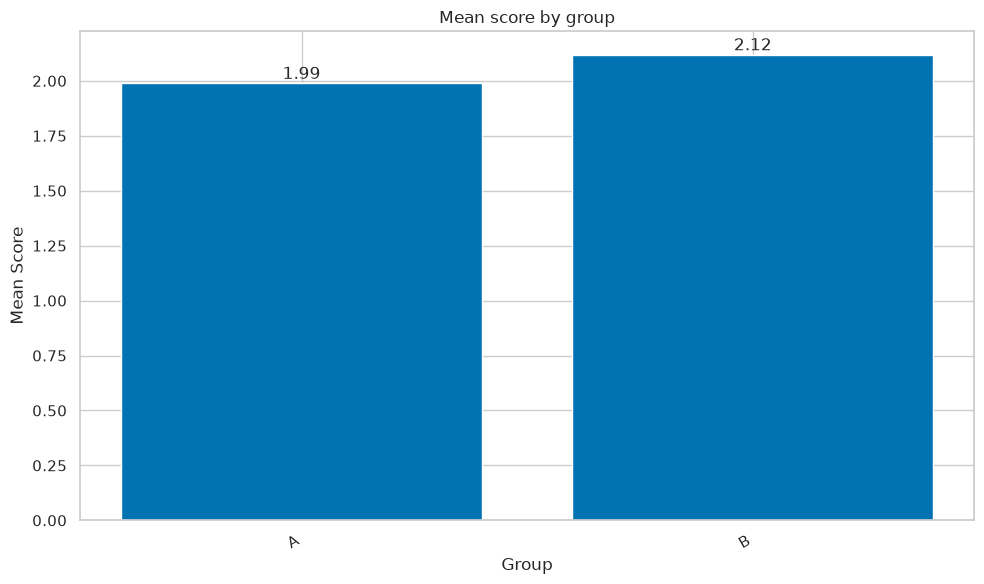

score.png ['fig_1.png']


In [18]:
# in scripts/CI: set MPLBACKEND=Agg (or matplotlib.use("Agg")) before importing siamang
import matplotlib.pyplot as plt
from pathlib import Path
import siamang as sg

score = sg.Variable("score", scale="ordinal", label="Score", labels={1: "Low", 2: "Mid", 3: "High"})
group = sg.Variable("group", scale="nominal", label="Group", labels={1: "A", 2: "B"})
survey = sg.Questionnaire(title="c", pages=[sg.Page("p", items=[
    sg.SingleChoice("Score?", var=score), sg.SingleChoice("Group?", var=group)])])
data = survey.simulate(n=200, seed=3)

Path("out").mkdir(exist_ok=True)                       # save() does not create directories
png = data.plot.bar("score", by="group", palette="colorblind", title="Mean score by group").save("out/score.png"); plt.show()
ax = data.plot.bar("score", horizontal=True).plot()    # matplotlib Axes for final touches
ax.set_xlabel("Respondents")
plt.close("all")                                       # figures are not closed for you

report = (sg.Report(title="Scores")
          .add(data.report.means("score", by="group"), caption="Table 1")
          .add(data.plot.boxplot("score", by="group", show_points=True), caption="Figure 1"))
report.save("out/scores.md")                           # writes fig_<block index>.png next to it
plt.close("all")
print(png.name, sorted(p.name for p in Path("out").iterdir() if p.name.startswith("fig_")))
# → score.png ['fig_1.png']

`Report.save()` chooses the format from the suffix (`.md`, `.html`); `.pdf` raises
`NotImplementedError` — render HTML and print it, or convert the Markdown with pandoc.
HTML output embeds images as data URIs, so it is a single portable file.

---

# Part C — Siamang Cloud (locally executable parts)

Siamang Cloud hosts the same code: a project is a Git repository with `siamang.yaml`, the
survey module, and analysis scripts that run on the platform against the collected
responses. Every commit is validated, deployments publish to a public URL, and runs produce
reports. The recipes below turn the Part A studies into Cloud projects. Platform-only
blocks are marked `# not run here`; the SDK's pure functions were executed locally.

## C1. Project layout and `siamang.yaml`

A project created from the **Template** or **Example** starting point has this shape;
copy a Part A study into it:

```text
civic-trust/
├── siamang.yaml               # wiring: survey entry, environments, analysis tasks, runtime
├── survey/
│   ├── codebook.py            # A1.1
│   └── questionnaire.py       # A1.2 (module-level `survey` and `options`)
├── scripts/
│   ├── cleaning.py            # C2.1
│   ├── weighting.py           # C2.2
│   └── tables.py              # C2.3
├── outputs/                   # what runs write (reports, xlsx, sav)
├── reports/                   # the combined "Run all" document
└── README.md                  # shown on the Dashboard
```

`siamang.yaml` for the Civic Trust study — a pilot and a main environment, three analysis
steps, the runtime packages, an insights block for the Dashboard, and one connector:

```yaml
name: "Civic Trust 2026"
org: "open-data-lab"
version: "1.0"

tasks:
  survey:
    type: survey
    entry: survey/questionnaire.py          # defines `survey` (+ `options` with the quota plan)
    environments:
      - { name: pilot, max_responses: 100 }
      - { name: main,  max_responses: 1200 }

  cleaning:
    type: analysis
    entry: scripts/cleaning.py
    description: "Dedup, drop partials and speeders, flatten payloads -> clean_responses"

  weighting:
    type: analysis
    entry: scripts/weighting.py
    description: "Rake to census margins -> weighted_responses"

  tables:
    type: analysis
    entry: scripts/tables.py
    description: "Labelled tables, weighted estimates, banner, SPSS export"
    report: outputs/tables.md
    outputs:
      - outputs/banner.xlsx
      - outputs/civic_trust.sav

  export_to_sheets:
    type: connector
    target: sheets
    direction: out
    table: weighted_responses
    secret: GSHEETS_SA                      # Project → Settings → Secrets (service-account JSON)
    config:
      spreadsheet_id: "1A2b3C4d5E6f7G8h9I0jKlMnOpQrStUvWxYz"

runtime:
  packages:
    - "siamang[charts]>=0.6"
    - "pandas>=2.0"
    - "numpy>=1.26"

reports:
  combined: reports/report.md               # written by "Run all"

insights:
  - type: stats
  - type: timeseries
  - type: frequency
    variable: trust_govt
    title: "Trust in the national government"
  - type: crosstab
    rows: trust_govt
    cols: region
```

What the platform reads: `name`, `org`, `tasks` (survey `entry` + `environments`; analysis
`entry` / `description` / `report` / `outputs`; connector `target` / `direction` / `table`
/ `secret` / `config`), `runtime.packages` (checked against an allowlist at commit time),
`reports.combined` and `insights`. The keys `version`, `database`, `storage`,
`runtime.python` and `reports.dir/formats` that appear in template files are reserved and
currently ignored. Data insights are off until the `insights:` block exists.

The survey module needs one adjustment for the Cloud: import the codebook relative to the
`survey/` directory (the platform runs the module from the repository root with
`survey/questionnaire.py` as the entry point):

```python
# not run here: survey/questionnaire.py on Siamang Cloud
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent))     # makes `codebook` importable

from codebook import variables                     # noqa: E402
# ... the rest of A1.2 unchanged: `survey = sg.Questionnaire(...)`, `options = {...}`
```

## C2. Analysis pipelines with the Cloud SDK

Scripts import `from siamang_cloud import db, analysis, respondents, Report`. Tables load as
pandas DataFrames (`db.table("responses").to_pandas()` flattens the JSON answers into one
column per key). The engine is installed in the sandbox too, so the labelled
`data.report.*` / `data.plot.*` layer is available once you wrap the frame in a
`SurveyData`. The sandbox has no network access, no secrets, and collects everything
written under `outputs/`.

### C2.1 Cleaning (`scripts/cleaning.py`)

```python
# not run here: scripts/cleaning.py — runs on Siamang Cloud
"""Step 1 — clean raw responses (type: analysis)."""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from siamang_cloud import db, respondents
from siamang.cli.loader import load_survey
from siamang.core import Matrix, MultiChoice
from siamang.core.question import question_output_name

sys.path.insert(0, str(Path("survey").resolve()))
survey = load_survey("survey/questionnaire.py")        # same module the deployment used


def flatten_responses(frame, survey):                  # identical to A1.4
    frame = frame.loc[:, ~frame.columns.str.startswith("__")].copy()
    for q in survey.all_questions():
        qid = question_output_name(q)
        if isinstance(q, Matrix) and qid in frame.columns:
            cells = frame.pop(qid)
            for v in q.var:
                frame[v.name] = cells.map(lambda d, n=v.name: d.get(n) if isinstance(d, dict) else np.nan)
        elif isinstance(q, MultiChoice) and q.mode == "wide" and qid in frame.columns:
            picks = frame.pop(qid)
            for v in q.var:
                frame[v.name] = picks.map(lambda s, n=v.name: int(n in s) if isinstance(s, list) else np.nan)
        elif q.other_specify and qid in frame.columns:
            frame[qid] = frame[qid].map(lambda d: d.get("selected") if isinstance(d, dict) else d)
    return frame


raw = db.table("responses").to_pandas()                # id, survey_id, respondent_id, partial, created_at, updated_at, + answers
df = respondents.dedup_responses(raw, id_col="respondent_id", order_by="updated_at")   # a resume updates, not duplicates
df = flatten_responses(df, survey)

df["is_partial"] = respondents.partial_flag(df, required=["consent", "age", "region", "trust_govt"])
df["duration_s"] = respondents.completion_time(df)     # NaN unless the payload carries duration_s
before = len(df)
df = df[~df["is_partial"]]
df = df[(df["consent"] == 1) & (df["age"] >= 18) & (df["region"] != 99)]

db.write_table("clean_responses", df, if_exists="replace")
print(f"clean_responses: {len(df)} of {before} deduplicated rows kept ({len(raw)} raw)")
```

### C2.2 Weighting (`scripts/weighting.py`)

```python
# not run here: scripts/weighting.py — runs on Siamang Cloud
"""Step 2 — rake to census margins (type: analysis)."""
from siamang_cloud import analysis, db

df = db.table("clean_responses").to_pandas()
CENSUS = {
    "region": {1: 0.31, 2: 0.24, 3: 0.27, 4: 0.18},
    "gender": {1: 0.51, 2: 0.48, 3: 0.01},
}
df["w"] = analysis.rake_weights(df, CENSUS)             # mean 1.0; pass its *name* as weight=
print(df.groupby("region")["w"].sum().div(df["w"].sum()).round(3).to_dict())
db.write_table("weighted_responses", df, if_exists="replace")
```

The SDK's `analysis` and `respondents` functions are plain pandas and run anywhere; this
is the same pipeline executed locally on a synthetic frame:

In [19]:
import numpy as np
import pandas as pd
from siamang_cloud import analysis, respondents

rng = np.random.default_rng(0)
n = 400
raw = pd.DataFrame({
    "respondent_id": [f"r{i:04d}" for i in range(n)],
    "updated_at": pd.date_range("2026-06-01", periods=n, freq="h"),
    "gender": rng.choice([1, 2, 3], n, p=[.55, .42, .03]),
    "age_group": rng.choice([1, 2, 3], n, p=[.45, .35, .20]),
    "work_mode": rng.choice([1, 2, 3], n),
    "life_satisfaction": rng.integers(1, 8, n).astype(float),
    "duration_s": rng.integers(60, 900, n).astype(float),
})
raw.loc[:5, "life_satisfaction"] = np.nan
resumed = raw.iloc[[0]].assign(updated_at=pd.Timestamp("2026-07-01"), life_satisfaction=7.0)
raw = pd.concat([raw, resumed], ignore_index=True)

df = respondents.dedup_responses(raw, id_col="respondent_id", order_by="updated_at")
df["is_partial"] = respondents.partial_flag(df, required=["gender", "age_group", "life_satisfaction"])
df = df[~df["is_partial"] & (df["duration_s"] >= 120)].copy()
df["w"] = analysis.rake_weights(df, {"gender": {1: .49, 2: .48, 3: .03},
                                     "age_group": {1: .32, 2: .36, 3: .32}})
print(len(raw), "->", len(df), "| mean weight", round(df["w"].mean(), 3),
      "| weighted gender shares", df.groupby("gender")["w"].sum().div(df["w"].sum()).round(2).to_dict())
freq = analysis.frequencies(df, "life_satisfaction", weight="w")          # value, count, percent
ct = analysis.crosstab(df, "work_mode", "life_satisfaction", weight="w", normalize="index")
test = analysis.chi2(df, "work_mode", "life_satisfaction")                # chi2, dof, p, cramers_v, n
print(freq.head(3).to_string(index=False)); print(round(test["p"], 3))

401 -> 358 | mean weight 1.0 | weighted gender shares {1: 0.49, 2: 0.48, 3: 0.03}
 value  count  percent
   1.0     60     16.8
   2.0     46     12.8
   3.0     42     11.8
0.812


### C2.3 Tables and the report (`scripts/tables.py`)

Two layers in one script: the SDK's quick tables (weighted, plain frames) and the engine's
labelled tables by wrapping the frame in `SurveyData` with the study codebook.

```python
# not run here: scripts/tables.py — runs on Siamang Cloud
"""Step 3 — labelled tables, weighted estimates, banner, SPSS export (type: analysis)."""
import sys
from pathlib import Path

import siamang as sg
from siamang_cloud import Report, analysis, db

sys.path.insert(0, str(Path("survey").resolve()))
from codebook import ACTIVITIES, TRUST_ITEMS, variables          # noqa: E402

if "weighted_responses" not in db.list_tables():
    sys.exit("weighted_responses not found — run the weighting step first (or Run all)")
df = db.table("weighted_responses").to_pandas()

# Engine layer: labelled tables, weighted statistics, banner
keep = [c for c in df.columns if c in variables or c == "w"]
data = sg.SurveyData(frame=df[keep], variables=variables)
data.variables.add(sg.Variable("w", scale="ratio", label="Raking weight", role="weight"))
data = data.with_weight("w").apply_missing_values()
data.tables.banner(rows=["trust_govt", "interest"], columns=["region", "gender"]).export_xlsx("outputs/banner.xlsx")
ess = data.analysis.effective_sample_size()

# SDK layer: quick weighted tables that drop straight into the report
sat = analysis.frequencies(df, "trust_govt", weight="w")
ct = analysis.crosstab(df, "region", "trust_govt", weight="w", normalize="index")
test = analysis.chi2(df, "region", "trust_govt")

(
    Report(title="Civic Trust 2026 — key tables",
           description="Weighted to census region x gender margins.")
    .value("Respondents", len(df)).value("Effective sample size", round(ess))
    .heading("Trust in the national government")
    .add(data.report.freq("trust_govt"), caption="Table 1. Trust in government (labelled, unweighted N)")
    .add(sat, caption="Table 2. Weighted distribution")
    .heading("Trust by region")
    .add(data.report.crosstab("region", "trust_govt", pct="row"), caption="Table 3. Row %, with chi-square")
    .add(ct.round(1), caption="Table 4. Weighted row %")
    .note(f"chi2={test['chi2']:.1f}, dof={test['dof']}, p={test['p']:.4f}, Cramér's V={test['cramers_v']:.2f}")
    .save("outputs/tables.md")
)

# A labelled SPSS file (Database → Export writes .sav without labels; SurveyData.export keeps them)
flat = data.with_frame(data.frame.drop(columns=["news_sources"], errors="ignore"))
flat.export("spss", path="outputs/civic_trust.sav")
print("report written to outputs/tables.md")
```

> **Note:** `db.as_survey_data()` in the current SDK falls back to a plain wrapper and does
> not attach the codebook; build the `SurveyData` yourself from the survey module's
> `variables`, as above. Reports accept engine tables, engine charts and pandas frames;
> save charts and files under `outputs/` so the run collects them.

## C3. Fieldwork operations

**Preview → pilot → main.** Deployments → *Preview* builds a staging survey that stores
nothing; walk it once before every deployment. Deploy `pilot` (cap 100 above), check the
Database and the Dashboard insights, then deploy `main`. The effective response limit is
the smaller of the environment cap and the plan cap (Free: 500 per project).

**Quotas.** The platform reads `options["quota"]` from the survey module, counts every
cell on completed submissions and shows the cells on the deployment card; a full
`max_responses` cap answers respondents with the "closed" screen (HTTP 409 at the ingest
API). Stop a deployment to close it (data stays), Redeploy after a fix.

**Watching the numbers.** Dashboard widgets (`insights:`) are live SQL aggregates over
everything collected; for anything weighted or labelled, run the analysis pipeline (C2)
— nightly on a schedule during fieldwork (C4).

**GDPR erasure.** Database → responses → Delete on the row; the deletion is written to the
organization's Activity log.

## C4. Automation and integrations

### Schedules (Plus and above)

From the project Console (backtick key):

```text
schedules
schedule add --cron "0 2 * * *" --all                # nightly Run all at 02:00 UTC
schedule add --cron "30 7 * * 1-5" --script tables   # weekday mornings, one task
schedule rm <id>
```

Cron is five fields in **UTC**; a "nightly at local midnight" job in UTC+2 is `0 22 * * *`.
Scheduled runs appear in Run history like manual ones.

### Connector tasks (Plus: sheets, excel365, supabase; Pro: storage, warehouses, database, sftp, redcap, http)

Destination settings always go under `config:`; credentials are a named project secret.
Each run replaces the destination table (CSV, all columns as text, 100,000-row cap;
50,000 for Google Sheets). Missing keys fail at run time with `<target>: missing config: …`.

```yaml
tasks:
  archive_to_s3:
    type: connector
    target: s3
    direction: out
    table: clean_responses
    secret: AWS_EXPORT                 # {"access_key": "...", "secret_key": "...", "region": "eu-central-1"}
    config:
      bucket: research-exports
      key: civic-trust/clean_responses.csv

  warehouse:
    type: connector
    target: bigquery
    direction: out
    table: weighted_responses
    secret: BQ_SERVICE_ACCOUNT         # service-account JSON
    config:
      dataset: research
      table: civic_trust_2026

  pull_sampling_frame:
    type: connector
    target: database                   # your own Postgres; secret holds a postgres:// DSN
    direction: in
    table: sampling_frame
    secret: FRAME_DB
    config: {}
```

### Webhooks (Plus and above): a receiver that verifies signatures

Organization settings → Integrations → add an endpoint URL, a secret, and **leave the
events list empty** to receive every event (`deploy.live`, `deploy.failed`,
`deploy.stopped`, `run.completed`, `run.failed`). Deliveries are JSON POSTs with
`X-Siamang-Event` and, when a secret is set, `X-Siamang-Signature: sha256=<hmac>` over the
raw body; failed deliveries are retried with back-off.

In [20]:
import hashlib
import hmac
import json
import warnings
warnings.simplefilter("ignore")   # silence the starlette test-client deprecation notice

from fastapi import FastAPI, Header, HTTPException, Request
from fastapi.testclient import TestClient

SECRET = "replace-me"
app = FastAPI()


def verify(secret: str, body: bytes, header: str | None) -> bool:
    expected = "sha256=" + hmac.new(secret.encode(), body, hashlib.sha256).hexdigest()
    return header is not None and hmac.compare_digest(expected, header)


@app.post("/siamang-hook")
async def hook(request: Request,
               x_siamang_event: str = Header(...),
               x_siamang_signature: str | None = Header(default=None)):
    body = await request.body()                      # raw bytes — never re-serialise before checking
    if not verify(SECRET, body, x_siamang_signature):
        raise HTTPException(401, "bad signature")
    event = json.loads(body)
    if x_siamang_event == "run.completed":
        print("run finished:", event.get("run_id"), event.get("script"))
    elif x_siamang_event == "deploy.live":
        print("survey live at", event.get("url"))
    return {"ok": True}


# Self-test with the same signing scheme the platform uses
client = TestClient(app)
payload = json.dumps({"event": "deploy.live", "url": "https://surveys.siamang.org/s/abc"}).encode()
sig = "sha256=" + hmac.new(SECRET.encode(), payload, hashlib.sha256).hexdigest()
ok = client.post("/siamang-hook", content=payload,
                 headers={"Content-Type": "application/json", "X-Siamang-Event": "deploy.live",
                          "X-Siamang-Signature": sig})
bad = client.post("/siamang-hook", content=payload,
                  headers={"Content-Type": "application/json", "X-Siamang-Event": "deploy.live",
                           "X-Siamang-Signature": "sha256=deadbeef"})
print(ok.status_code, bad.status_code)
# → 200 401

survey live at https://surveys.siamang.org/s/abc
200 401


To post into Slack, let this receiver forward a formatted message to a Slack incoming
webhook; Slack's endpoint does not accept the Siamang payload directly.

## C5. Working from your own machine and the REST API

**Clone, edit, validate, push.** Repository → Remotes shows the HTTPS clone command with a
token (register a public key under Profile → SSH keys for SSH). Every push is validated
exactly like a browser commit; protect `main` (Settings → Git) so only validated commits
land.

```bash
git clone https://app.siamang.org/git/open-data-lab/civic-trust.git
cd civic-trust
PYTHONPATH=survey siamang validate survey/questionnaire.py --strict   # same check the platform runs
MPLBACKEND=Agg PYTHONPATH=survey python -m pytest -q survey/           # your smoke tests
git commit -am "Tighten the region quota" && git push
```

**Personal API keys.** Profile → API keys → New key gives `sck_…` once; send it as
`Authorization: Bearer sck_…` to `https://api.siamang.org`. The key acts as you, with your
role in each organization. Useful calls (project ids come from the projects list):

```bash
API=https://api.siamang.org; TOKEN=sck_...; AUTH="Authorization: Bearer $TOKEN"
curl -s -H "$AUTH" $API/auth/me                                          # who am I, memberships
curl -s -H "$AUTH" $API/orgs/open-data-lab/projects                       # → [{id, slug, name, ...}]
curl -s -H "$AUTH" -X POST $API/projects/42/deployments \
     -H "Content-Type: application/json" -d '{"environment": "pilot", "branch": "main"}'
curl -s -H "$AUTH" $API/projects/42/deployments                           # status: building / live / stopped
curl -s -H "$AUTH" -X POST $API/projects/42/scripts/run-all              # → a run row {id, status, ...}
curl -s -H "$AUTH" $API/projects/42/runs                                  # run history
curl -s -H "$AUTH" -o clean.xlsx "$API/projects/42/database/tables/clean_responses/export?format=xlsx"
curl -s -H "$AUTH" -X POST $API/projects/42/schedules -H "Content-Type: application/json" \
     -d '{"kind": "run_all", "cron": "0 2 * * *", "branch": "main"}'
```

The same from Python, polling a run until it finishes:

```python
# not run here: needs an API key and a project on Siamang Cloud
import time
import requests

API = "https://api.siamang.org"
S = requests.Session()
S.headers["Authorization"] = "Bearer sck_..."

project = next(p for p in S.get(f"{API}/orgs/open-data-lab/projects").json() if p["slug"] == "civic-trust")
run = S.post(f"{API}/projects/{project['id']}/scripts/run-all").json()
while run["status"] not in ("success", "completed", "failed"):
    time.sleep(10)
    run = next(r for r in S.get(f"{API}/projects/{project['id']}/runs").json() if r["id"] == run["id"])
print(run["status"])

xlsx = S.get(f"{API}/projects/{project['id']}/database/tables/clean_responses/export",
             params={"format": "xlsx"})
open("clean_responses.xlsx", "wb").write(xlsx.content)
```

Export formats at the API and in Database → Export: `csv`, `xlsx`, `sav` (data only — no
labels; use `SurveyData.export("spss")` in an analysis script for a labelled file),
`parquet`, `sqlite`, `json`.

---